***Customer Churn Analysis***

This project analyzes telecom customer churn data to identify factors
that influence customer retention and churn behavior.

***Problem Statement***


Customer churn occurs when customers stop using a company's service.
Understanding churn patterns helps businesses improve customer retention.

Goal of this analysis:
- Identify churn patterns
- Understand key factors influencing churn
- Provide insights to reduce churn

***Analysis*** 

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df=pd.read_csv(r"C:\Users\vsaro\customer-churn-analysis\dataset\churn_data.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
df.isnull().sum()

In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df['Churn'].value_counts()

In [ ]:
sns.countplot(x='Churn',data=df)
plt.title("Customer Churn Distribution")
plt.show()

***Insights:Customer Churn Distribution***

- Most customers stays
- Some customers leave

In [ ]:
sns.countplot(x='Contract',hue='Churn', data=df)
plt.title("Churn by Contract type")
plt.show()



***Insights:Churn by Contract type***

- Customers who have month to month contract tend to churn more.
- Customers with 1 year contract churn less.


In [ ]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

***Insights***
- Customers with higher monthly charges show significantly higher churn.
- This suggests pricing may be a major factor influencing customer retention.

In [ ]:
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title(" Customer Tenure vs Churn")
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Month)')
plt.show()

### Insights

- Customers with shorter tenure are more likely to churn.
- Customers who stay longer with the company tend to remain loyal.
- This indicates that churn risk is highest during the early customer lifecycle.
- Improving early customer engagement may help reduce churn.

In [ ]:
sns.countplot(x='InternetService',data=df)
plt.title("Churn by Internet Service")
plt.show()

### Insight

- Fibre optic customers show higher churn compared to others

In [ ]:
sns.countplot(x='PaymentMethod',hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

### Insight
- Customers with payment method as Electronic check churn more.

In [ ]:
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.title("Churn by Senior Citizen")
plt.show()

### Insight

-  It indicates Senior citizen stay with the company.

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Insights

- Tenure and MonthlyCharges show a weak positive correlation (0.25), indicating customers who stay longer tend to pay slightly higher monthly charges.
- SeniorCitizen has almost no correlation with tenure (0.02), suggesting age group does not strongly influence how long customers stay.
- Overall, the numerical features show weak correlations, indicating churn behavior may depend more on categorical factors like contract type and internet service.

### Conclusion

- Customers with month-to-month contracts have the highest churn rate.
- Customers with shorter tenure are more likely to leave the service.
- Higher monthly charges are associated with increased churn.
- Long-term contracts and better early customer engagement could help reduce churn.

# Machine Learning - Customer Churn Prediction

In [10]:
df_ml = df.drop('customerID', axis=1).copy()

In [11]:
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

In [12]:
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

In [13]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())



Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X_train.select_dtypes(include='object').columns
numeric_cols = X_train.select_dtypes(exclude='object').columns

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Categorical columns: 16
Numeric columns: 3


In [16]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Before encoding:", X_train.shape)
print("After encoding:", X_train_processed.shape)

Before encoding: (5634, 19)
After encoding: (5634, 5320)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_processed, y_train)

y_pred = lr_model.predict(X_test_processed)
y_prob = lr_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1 Score : 0.5821
ROC-AUC  : 0.8403


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Accuracy : 0.7864
Precision: 0.6205
Recall   : 0.5027
F1 Score : 0.5554
ROC-AUC  : 0.8205


In [20]:
import xgboost as xgb

print(xgb.__version__)

3.2.0


In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))

Accuracy : 0.8013
Precision: 0.6632
Recall   : 0.5107
F1 Score : 0.577
ROC-AUC  : 0.8401


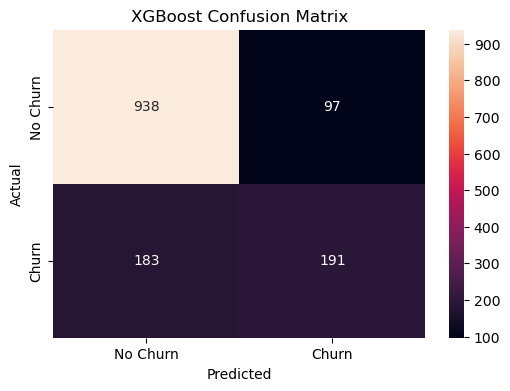

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

In [23]:
# Threshold tuning for Logistic Regression

y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]

threshold = 0.40

y_pred_lr_40 = (y_prob_lr >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr_40), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr_40), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr_40), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr_40), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))

Threshold: 0.4
Accuracy : 0.7764
Precision: 0.5688
Recall   : 0.6524
F1 Score : 0.6077
ROC-AUC  : 0.8403


In [24]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4)
    })

threshold_results

[{'Threshold': 0.3,
  'Accuracy': 0.753,
  'Precision': 0.5242,
  'Recall': 0.754,
  'F1 Score': 0.6184},
 {'Threshold': 0.35,
  'Accuracy': 0.7679,
  'Precision': 0.5497,
  'Recall': 0.6952,
  'F1 Score': 0.6139},
 {'Threshold': 0.4,
  'Accuracy': 0.7764,
  'Precision': 0.5688,
  'Recall': 0.6524,
  'F1 Score': 0.6077},
 {'Threshold': 0.45,
  'Accuracy': 0.7963,
  'Precision': 0.616,
  'Recall': 0.6176,
  'F1 Score': 0.6168},
 {'Threshold': 0.5,
  'Accuracy': 0.7942,
  'Precision': 0.6312,
  'Recall': 0.5401,
  'F1 Score': 0.5821}]

In [25]:
threshold = 0.45

y_pred_final = (y_prob_lr >= threshold).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)

print(cm_final)


[[891 144]
 [143 231]]


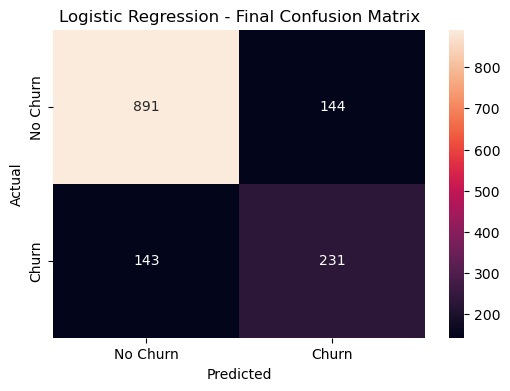

In [26]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Final Confusion Matrix')
plt.show()

In [27]:
# Predict churn probability for all customers

X_processed = preprocessor.transform(X)

churn_probability = lr_model.predict_proba(X_processed)[:, 1]

customer_predictions = df[['customerID']].copy()

customer_predictions['Churn_Probability'] = churn_probability

customer_predictions['Risk'] = customer_predictions['Churn_Probability'].apply(
    lambda x: 'High' if x >= 0.45 else 'Low'
)

customer_predictions.head(10)

,customerID,Churn_Probability,Risk
0,7590-VHVEG,0.448932,Low
1,5575-GNVDE,0.047017,Low
2,3668-QPYBK,0.412726,Low
3,7795-CFOCW,0.034710,Low
4,9237-HQITU,0.737290,High
5,9305-CDSKC,0.839493,High
6,1452-KIOVK,0.499133,High
7,6713-OKOMC,0.269190,Low
8,7892-POOKP,0.693619,High
9,6388-TABGU,0.013103,Low


In [28]:
customer_predictions['Risk'].value_counts()

Risk
Low     5257
High    1786
Name: count, dtype: int64

In [29]:
customer_predictions.sort_values(
    'Churn_Probability',
    ascending=False
).head(10)

,customerID,Churn_Probability,Risk
4624,0325-XBFAC,0.900961,High
3467,8414-MYSHR,0.885105,High
1976,9497-QCMMS,0.884167,High
4800,9300-AGZNL,0.883637,High
6368,2720-WGKHP,0.880570,High
2208,7216-EWTRS,0.879672,High
1436,9546-CQJSU,0.878880,High
5989,5567-WSELE,0.878187,High
1410,7024-OHCCK,0.878106,High
1205,6358-LYNGM,0.877662,High


In [30]:
# Creating  final dataset for Power BI

powerbi_data = df.copy()

powerbi_data['Churn_Probability'] = churn_probability

powerbi_data['Risk'] = powerbi_data['Churn_Probability'].apply(
    lambda x: 'High' if x >= 0.45 else 'Low'
)

powerbi_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Probability,Risk
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0.448932,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,0.047017,Low
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0.412726,Low
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0.034710,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0.737290,High


In [31]:
powerbi_data.to_csv(
    'customer_churn_predictions.csv',
    index=False
)

In [32]:
print(powerbi_data.shape)
print(powerbi_data.columns)

(7043, 23)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_Probability', 'Risk'],
      dtype='object')
